Instalar las siguientes librerias y reiniciar el kernel

In [4]:
# !pip install tensorflow
# !pip install keras
# !pip intall --upgrade keras
# !pip install ipympl

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
from matplotlib import cm
from formulaic import Formula

from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from time import time
import logging
import os

# Estas dos lineas son para silenciar las advertencias de TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# La siguiente linea es para que tensorflow no use la GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
import keras

# Redes Neuronales

### Laboratorio de Datos, IC - FCEN - UBA - Verano 2026

### 1. Perceptrón Simple : clasificación binaria 

Armaremos una red neuronal para predecir si una persona tiene o no diabetes a partir de 8 caracteristicas:
- Embarazos
- Glucosa
- Presión sanguínea
- Grosor de la piel
- Insulina
- Indice de masa corporal (BMI)
- Antecedentes familiares
- Edad

Como se trata de un problema de clasificación, la función de activación será la función sigmoidea.

In [8]:
# Cargamos el dataset y descartamos las observaciones con campos faltantes
data = pd.read_csv('diabetes.csv')
data.dropna(inplace=True)

# Definimos las variables.
X = data.drop('Outcome', axis=1)    # Queremos todas las columnas salvo Outcome
y = data['Outcome']

In [9]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [10]:
# Separamos entrenamiento y testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# En pro de la reproducibilidad, especificamos la semilla para keras
keras.utils.set_random_seed(11)

# Paso 1: iniciamos el modelo indicando la arquitectura de la red
model = keras.Sequential([
    keras.layers.Input(shape=(8,)),             # Capa de input: indicamos que el input tiene dimension 8
    keras.layers.Dense(1,                       # Capa de output: el output tiene dimension 1 (clasificacion binaria)
                       activation='sigmoid')    # y su funcion de activacion es la sigmoidea.
])

E0000 00:00:1773083102.165191   18220 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
# Paso 2: configuramos el optimizador: usaremos Descenso por Gradiente Estocástico con learning rate constante 0.5
# Documentacion SGD : https://keras.io/api/optimizers/sgd/ 
optimizer = keras.optimizers.SGD(learning_rate=0.05)

In [13]:
# Paso 3: construimos el modelo
model.compile(
    optimizer=optimizer,            # Optimizador a utilizar
    loss='binary_crossentropy',     # Funcion de perdida para clasificacion binaria
    metrics=['accuracy',            # Metricas a registrar durante el entrenamiento
             'false_negatives']            
)

In [14]:
# Paso 4: entrenamiento del modelo. 
# model.fit devuelve un objeto History que guarda la evolucion del valor de la funcion de perdida y de las metricas 
# luego de cada epoca.
hist = model.fit(X_train.to_numpy(), y_train.to_numpy(),    # Ingresamos los datos de entrenamiento
                 epochs=150,                                 # Especificamos la cantidad de épocas
                 batch_size=20,                             # Especificamos el tamaño del batch
                 validation_split=0.2,                      # 20% de datos para validación
                 verbose=0,                                 # Opcional, para que no muestre el proceso de entrenamiento.
                 )

In [15]:
# Paso 5: calculamos el error en el conjunto de testeo
model.evaluate(X_test.to_numpy(), y_test.to_numpy(),
               verbose=0,
               batch_size=len(y_test),
               return_dict=True
               )

{'accuracy': 0.7337662577629089,
 'false_negatives': 30.0,
 'loss': 0.5537289977073669}

In [16]:
# Armamos una funcion para graficar el error a través de las épocas
def graficar_error(history, error_name):
    x_arr = np.array(history.epoch)    # en el atributo epoch, history guarda una lista de epocas
    plot = (
        so.Plot()
        .add(so.Line(color='blue'), x=x_arr, y=history.history[error_name], label='Entrenamiento')
        .add(so.Line(color='orange'), x=x_arr, y=history.history[f'val_{error_name}'], label='Validacion')
        .label(title=error_name)
    )
    plot.show()

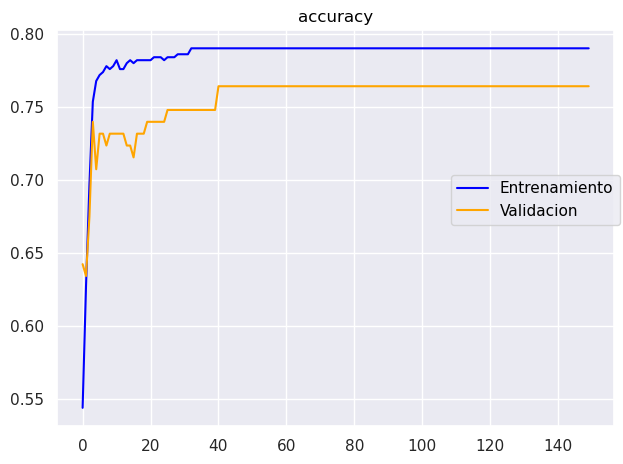

In [17]:
graficar_error(hist, 'accuracy')  # Probar también "loss"

Analizando los pesos, podemos interpretar qué factor es más influyente en el diagnóstico de diabetes

In [18]:
# Aqui se guardan los pesos en la primera coordenada y el bias en la segunda
weights, bias = model.layers[0].get_weights()

# Convertimos a series
weights = weights.flatten()

# Armamos una Serie para simplificar el análisis
pd.Series(weights, index=X_train.columns, name='Peso en la RN')

Pregnancies      0.433441
Glucose          1.256359
BloodPressure   -0.231667
SkinThickness    0.013804
Insulin         -0.161855
BMI              0.690373
Pedigree         0.347968
Age              0.258166
Name: Peso en la RN, dtype: float32

### 2. Perceptrón Simple : clasificación en más de dos categorías

Ahora, dadas las cuatro características de los pingüinos (peso, longitud de aleta y profundidad y longitud del pico), 
intentaremos predecir de qué especie es (Adelie, Chinstrap o Gentoo).

In [19]:
# Cargamos el dataset y descartamos las observaciones con campos faltantes
penguins = sns.load_dataset('penguins')
penguins.dropna(inplace=True)

# Como en el dataset los pinguinos estan ordenados por especie, estaria bueno mezclar el DataFrame
penguins = penguins.sample(len(penguins))

# Definimos las variables.
X = penguins[['bill_length_mm', 'flipper_length_mm', 'bill_depth_mm', 'body_mass_g']]
# Armamos una Serie las etiquetas: 0 corresponde a Gentoo, 1 corresponde a Adelie, 2 corresponde a Chinstrap
y = penguins['species'].apply(lambda x: 1*(x == 'Adelie') + 2*(x == 'Chinstrap'))    

# Separamos entrenamiento y testeo y escalamos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
keras.utils.set_random_seed(11)

# Paso 1: iniciamos el modelo indicando la arquitectura de la red
model = keras.Sequential([
    keras.layers.Input(shape=(4,)),             # Capa de input: indicamos que el input tiene dimension 4
    keras.layers.Dense(3,                       # Capa de output: el output tiene dimension 3 (una neurona para cada especie)
                       activation='softmax')    # y su funcion de activacion es softmax f_i = e^(z_i) / suma_j e^(z_j)
                                                # (similar a sigmoidea pero normaliza para que sean todos valores positivos y con suma 1).
])

# Paso 2: configuramos el optimizador
optimizer = keras.optimizers.SGD(learning_rate=0.5)

# Paso 3: construimos el modelo
model.compile(
    optimizer=optimizer,                        
    loss='sparse_categorical_crossentropy',     # Funcion de perdida para clasificacion con mas de dos categorias
    metrics=['accuracy']                        
)

# Paso 4: entrenamiento del modelo. 
hist = model.fit(X_train.to_numpy(), y_train.to_numpy(),    
                 epochs=150,                                 
                 batch_size=20,                             
                 validation_split=0.2,                      
                 verbose=0,  
                 )

# Paso 5: calculamos el error en el conjunto de testeo
model.evaluate(X_test.to_numpy(), y_test.to_numpy(),
               verbose=0,
               batch_size=len(y_test),
               return_dict=True
               )

{'accuracy': 0.9850746393203735, 'loss': 0.0252191424369812}

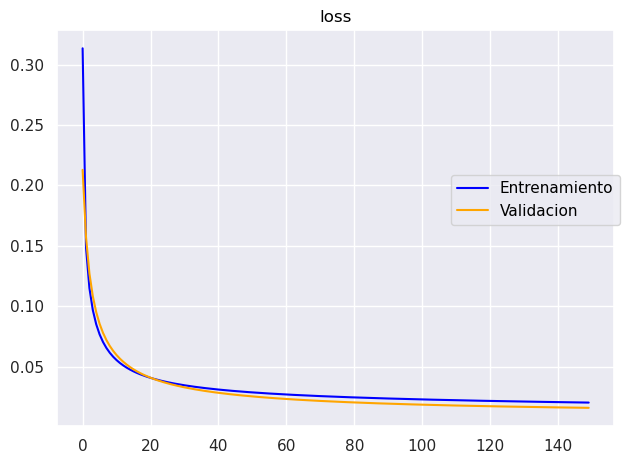

In [21]:
# Graficamos la evolucion de la precision de la clasficiacion
graficar_error(hist, 'loss')

### 3. Perceptrón Multicapa

In [22]:
data = pd.read_csv('nutrition.csv')
data.isna().sum()

FDC_ID                0
Item                  0
Category              0
Calorias_kcal         0
Proteinas_g           0
Carbohidratos_g       0
GrasaTotal_g          0
Colesterol_mg       399
Fibra_g             562
Agua_g                0
Alcohol_g          2394
VitaminaC_mg        461
dtype: int64

In [23]:
data

,FDC_ID,Item,Category,Calorias_kcal,Proteinas_g,Carbohidratos_g,GrasaTotal_g,Colesterol_mg,Fibra_g,Agua_g,Alcohol_g,VitaminaC_mg
0,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",Baked Products,307.0,5.88,41.18,13.24,0.0,1.2,35.50,NaN,NaN
1,167513,"Pillsbury, Cinnamon Rolls with Icing, refriger...",Baked Products,330.0,4.34,53.42,11.27,0.0,1.4,27.86,NaN,0.1
2,167514,"Kraft Foods, Shake N Bake Original Recipe, Coa...",Baked Products,377.0,6.10,79.80,3.70,NaN,NaN,3.20,NaN,NaN
3,167515,"George Weston Bakeries, Thomas English Muffins",Baked Products,232.0,8.00,46.00,1.80,NaN,NaN,42.60,NaN,NaN
4,167516,"Waffles, buttermilk, frozen, ready-to-heat",Baked Products,273.0,6.58,41.05,9.22,15.0,2.2,40.34,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
7788,175300,"Game meat, buffalo, water, cooked, roasted","Lamb, Veal, and Game Products",131.0,26.83,0.00,1.80,61.0,0.0,68.81,NaN,0.0
7789,175301,"Game meat, elk, raw","Lamb, Veal, and Game Products",111.0,22.95,0.00,1.45,55.0,0.0,74.38,NaN,0.0
7790,175302,"Game meat, elk, cooked, roasted","Lamb, Veal, and Game Products",146.0,30.19,0.00,1.90,73.0,0.0,66.28,NaN,0.0
7791,175303,"Game meat, goat, raw","Lamb, Veal, and Game Products",109.0,20.60,0.00,2.31,57.0,0.0,75.84,NaN,0.0


In [24]:
data.shape

(7793, 12)

In [25]:
data.dropna(inplace=True)
data.columns

Index(['FDC_ID', 'Item', 'Category', 'Calorias_kcal', 'Proteinas_g',
       'Carbohidratos_g', 'GrasaTotal_g', 'Colesterol_mg', 'Fibra_g', 'Agua_g',
       'Alcohol_g', 'VitaminaC_mg'],
      dtype='object')

In [26]:
X = data.drop(columns=['FDC_ID', 'Item', 'Category', 'Calorias_kcal'])
y = data['Calorias_kcal']

# Separamos entrenamiento y testeo y escalamos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
X_train

,Proteinas_g,Carbohidratos_g,GrasaTotal_g,Colesterol_mg,Fibra_g,Agua_g,Alcohol_g,VitaminaC_mg
1704,-0.982875,-0.638626,-0.638246,-0.448222,-0.177979,1.322560,-0.072746,0.191749
3914,0.822042,-0.708610,-0.470599,0.200394,-0.419643,0.611234,-0.072746,-0.108956
2944,-0.769850,-0.492759,-0.528095,-0.364530,-0.419643,1.054058,-0.072746,-0.096234
1725,-1.042593,-0.376380,-0.644298,-0.448222,-0.008813,1.140020,-0.072746,-0.016432
7290,-0.748459,-0.171538,-0.585592,-0.427299,0.547016,0.786925,-0.072746,-0.096234
...,...,...,...,...,...,...,...,...
6627,-0.343801,1.285555,-0.043918,-0.385453,-0.129646,-0.995671,-0.072746,-0.108956
1800,-1.014071,-0.576898,-0.637035,-0.448222,-0.153812,1.291395,-0.072746,0.087659
102,-0.824221,1.275726,-0.487546,-0.448222,0.812848,-0.511408,-0.072746,-0.108956
1208,-1.063093,-0.168000,-0.627352,-0.448222,0.281185,0.936930,-0.072746,-0.043032


In [28]:
y_train

1704     12.0
3914    120.0
2944     56.0
1725     35.0
7290     81.0
        ...  
6627    328.0
1800     16.0
102     239.0
1208     54.0
7781    146.0
Name: Calorias_kcal, Length: 4264, dtype: float64

In [29]:
class PrintWeights(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        w, b = self.model.layers[0].get_weights()
        print(f"Epoch {epoch+1:3d} | w = {w.flatten()} | b = {b[0]:.6f} | loss = {logs['loss']:.6f}")


In [30]:
keras.utils.set_random_seed(11)

# Paso 1: iniciamos el modelo indicando la arquitectura de la red
model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)), 
    keras.layers.Dense(2, activation="softmax"),
    keras.layers.Dense(1, activation="relu")    
])

# Paso 2: configuramos el optimizador
optimizer = keras.optimizers.SGD(learning_rate=0.01)

# Paso 3: construimos el modelo
model.compile(
    optimizer=optimizer,                        
    loss='mean_squared_error',                    
)

# Paso 4: entrenamiento del modelo. 
hist = model.fit(X_train.to_numpy(), y_train.to_numpy(),    
                 epochs=20,                                 
                 batch_size=20,                             
                 validation_split=0.2,                      
                 verbose=0,        
                 callbacks=[PrintWeights()]                 
                 )


Epoch   1 | w = [ 12.27853    -12.852485     6.870343    -6.942066    21.364933
 -21.496143    -8.629605     8.730735     4.8527594   -4.707615
 -22.890337    22.113323    -0.19434991   1.1278439   -2.175997
   2.0961263 ] | b = 0.042521 | loss = 21346.441406
Epoch   2 | w = [ -0.14973831  -0.42419672   3.250484    -3.3222003   39.245937
 -39.377155    -3.444774     3.545904     2.1378393   -1.9926888
 -24.484642    23.707623     0.7158448    0.21765596 -13.455275
  13.375374  ] | b = -12.473928 | loss = 11614.680664
Epoch   3 | w = [ -1.7013271    1.1273926   18.089312   -18.161032    35.988426
 -36.119663    -3.9834144    4.084549     2.8055005   -2.6603556
 -35.48091     34.70389      0.57585543   0.3576433  -12.066218
  11.986314  ] | b = -10.535548 | loss = 11052.740234
Epoch   4 | w = [ 10.452642   -11.026569    15.752454   -15.824177    39.1601
 -39.291344    -0.12230649   0.2234102   -2.5398355    2.6849892
 -40.41485     39.63782     13.006253   -12.072757    -5.45138
   5.371

In [31]:
# Paso 5: calculamos el error en el conjunto de testeo
model.evaluate(X_test.to_numpy(), y_test.to_numpy(),
               verbose=0,
               batch_size=len(y_test),
               return_dict=True
               )

{'loss': 11553.328125}

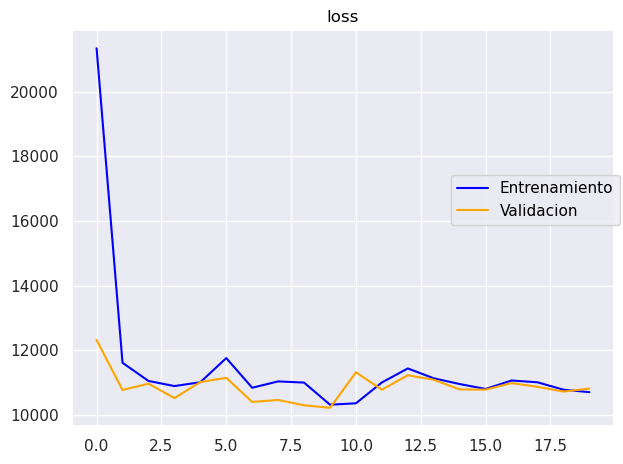

In [32]:
graficar_error(hist, 'loss')

## Ejercicio

Entontrar una red neuronal que ajuste los datos de coronavirus (sin transformar la variable y)

In [ ]:
coro = pd.read_csv('casos_coronavirus.csv')
coro.reset_index(inplace=True)      # Reseteamos el índice para trabajar con los indices en vez de las fechas
so.Plot(data=coro, x='index', y='confirmados_Nuevos').add(so.Dot())